<a href="https://colab.research.google.com/github/Asmitx026/SEM-V_BWU_AI-Lab/blob/main/assignment_3_day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Q1. Dump a python dictionary to a json file.

In [ ]:
import json

std_asmit = {
    'name': 'Asmit',
    'department': 'CSE-AIML',
    'semester': 4,
    'courses': ['DBMS', 'AI', 'COA', 'DeepL']
}

with open('std_asmit.json', 'w') as fp:
    json.dump(std_asmit, fp, indent=4)

### Q2. Apply prediction after training a KNN model on the iris dataset (UCI ML) from kaggelhub and evaluate the predictions.

In [ ]:
from google.colab import userdata
userdata.get('KAGGLE_API_TOKEN')
import kagglehub
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

path = kagglehub.dataset_download('uciml/iris')
print(f'Path to the dataset: {path}')

Using Colab cache for faster access to the 'iris' dataset.
Path to the dataset: /kaggle/input/iris


In [ ]:
iris = pd.read_csv(f'{path}/Iris.csv')
print('First 5 rows:')
display(iris.head())

iris['Species'] = iris['Species'].str.replace('Iris-', '')

print(f'\nUnique Species: {iris['Species'].unique()}\n')
print(iris['Species'].value_counts())

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Unique Species: ['setosa' 'versicolor' 'virginica']

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
X = iris.iloc[:, 1:5]
y = iris['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]



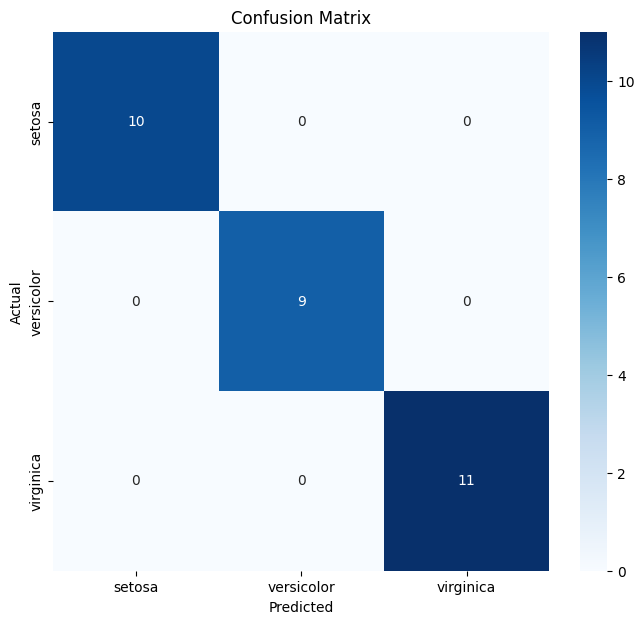

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{cm}\n')

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xticklabels(iris['Species'].unique())
ax.set_yticklabels(iris['Species'].unique())
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.show()

### Q3. Perform DFS and BFS on a undirected graph

In [1]:
def bfs(adj: list[list[int]]) -> list[int]:
    V = len(adj)
    visited = [False] * len(adj)
    res = []

    src = 0
    visited[src] = True
    q = []
    q.append(src)

    while q:
        curr = q.pop(0)
        res.append(curr)

        for v in adj[curr]:
            if not visited[v]:
                visited[v] = True
                q.append(v)
    return res

In [2]:
def dfsRec(adj: list[list[int]], visited: list[bool], src: int, res: list[int]):
    visited[src] = True
    res.append(src)

    for i in adj[src]:
        if not visited[i]:
            dfsRec(adj, visited, i, res)


def dfs(adj: list[list[int]]):
    visited = [False] * len(adj)
    res = []
    dfsRec(adj, visited, 0, res)
    return res

In [4]:
def addEdge(graph: list[list[int]], u: int, v: int) -> None:
    graph[u].append(v)
    graph[v].append(u)

def main() -> None:
    V = int(input("Enter the no. of vertices: "))
    graph = [[] for _ in range(V)]

    while True:
        u = int(input("\nEnter the value of u: "))
        v = int(input("Enter the value of v: "))
        addEdge(graph, u, v)
        print(f"Edge Added: ({u},{v})")

        choice = input("Do you want to add more edges? (y/n): ")
        if choice.lower() != 'y':
            break

    print(f"Graph: {graph}")

    res_bfs = bfs(graph)
    print(f"\nBFS: {res_bfs}")

    res_dfs = dfs(graph)
    print(f"\nDFS: {res_dfs}")

if __name__ == '__main__':
    main()

Enter the no. of vertices: 4

Enter the value of u: 0
Enter the value of v: 1
Edge Added: (0,1)
Do you want to add more edges? (y/n): y

Enter the value of u: 0
Enter the value of v: 2
Edge Added: (0,2)
Do you want to add more edges? (y/n): y

Enter the value of u: 1
Enter the value of v: 2
Edge Added: (1,2)
Do you want to add more edges? (y/n): y

Enter the value of u: 2
Enter the value of v: 3
Edge Added: (2,3)
Do you want to add more edges? (y/n): n
Graph: [[1, 2], [0, 2], [0, 1, 3], [2]]

BFS: [0, 1, 2, 3]

DFS: [0, 1, 2, 3]
